In [8]:
import pandas as pd
import numpy as np
from pandas_datareader import data
import matplotlib.pyplot as plt
import plotly.express as px
import yfinance as yf

In [62]:
# =======================================================================================
# Functions needed for this code
# =======================================================================================

# =========================================================
# Data Frame Generation
# =========================================================

def Data_Frame_Stocks_Generation(basket_options, start_day, end_day):
    # Based on yahoo finance, I save all the information in the data frame
    df = yf.download(basket_options, start=start_day, end=end_day)

    # Print the entire data frame
    display(df)
    
    # Filter the data only using the close price
    df_stocks_close = df['Close']

    # Print only the column of close
    display(df_stocks_close)

    return df_stocks_close

def Generate_Plot(data_frame):
    figure = px.line(title="History of the stock prices", width=1000, height=600)
    
    for i in data_frame.columns:
        figure.add_scatter(x=data_frame.index, y=data_frame[i], name=i)
        
    figure.show()
    return 0


def Generate_Normalized_Plot(data_frame):
    
    figure = px.line(title="History of the Normalized stock prices", width=1000, height=600)

    for i in data_frame.columns:
        # Normalized plots (divide by the first element)
        figure.add_scatter(x=data_frame.index, y=data_frame[i]/data_frame[i].iloc[0], name=i)
        
    figure.show()
    return 0

# =========================================================
# Parameter Estimation
# =========================================================

def Log_Return_Calculator(df_basket):
    # Apply the log(r_t/r_{t-1})
    df_returns = np.log(df_basket / df_basket.shift(1)).dropna()
    
    return df_returns

def Annualized_Standard_Deviation(df_basket,Num_day):
    # Daily volatility
    daily_std = df_basket.std() 
    year_std = daily_std * np.sqrt(Num_day)

    # We could have used other estimators
    # 1. Parkinson
    # 2. Garman-Klass
    return year_std

def Annualized_Covariance_Matrix(df_basket,Numday):
    # 1. Daily covariance matrix
    cov_day = df_basket.cov()

    # 2. Covariance of the entire year
    # Here we don't have the square root!
    cov_anual = cov_day * Numday

    return cov_anual

# =========================================================
# Simulation of the Basket_Prices
# =========================================================

def Simulate_Basket_Prices(df_basket, MCov, annualized_volatility, r, T, M):
    """
    Simulates future asset prices of a basket using Monte Carlo and Cholesky decomposition.
    
    Parameters:
    df_basket             : Original DataFrame with historical close prices
    L                     : Lower triangular matrix obtained from Cholesky decomposition of MCov
    annualized_volatility : Series containing the annualized volatility of each asset
    r                     : Annual risk-free rate (e.g., 0.105 for 10.5%)
    T                     : Time to maturity in fractions of a year (e.g., 0.5 for 6 months)
    M                     : Number of simulations/scenarios 
    
    Returns:
    S_T                   : NumPy matrix (N_assets x M) with the projected prices at maturity
    """
    # Find the number of assets in the basket
    N_assets = df_basket.shape[1]
    
    # Initial Spot Price (S0) -> Extract the last valid row from history
    S0 = df_basket.iloc[-1].values 
    
    # 1. Generate independent standard normal random numbers (Z ~ N(0,1))
    Z = np.random.normal(0, 1, size=(N_assets, M))
    
    # 2. Matrix multiplication to correlate the random shocks
    L = np.linalg.cholesky(MCov)
    correlated_shocks = np.dot(L, Z)
    
    # 3. Initialize the matrix that will store the final projected prices
    S_T = np.zeros((N_assets, M))
    
    # 4. Project the price of each asset using the GBM formula (Geometric Brownian Motion)
    for i in range(N_assets):
        drift = (r - (annualized_volatility.iloc[i] ** 2) / 2) * T
        diffusion = correlated_shocks[i] * np.sqrt(T)
        
        S_T[i] = S0[i] * np.exp(drift + diffusion)
        
    return S_T

def Price_Basket_Option(df_simulations, weights_basket, K, r, T, option_type="call"):
    """
    Calculates the final fair value of a basket option using the simulated asset prices.
    
    Parameters:
    df_simulations : DataFrame containing the simulated prices at maturity (M rows x N_assets columns)
    weights_basket : NumPy array with the weights of each asset (e.g., [0.8, 0.2])
    K              : Strike price of the basket option
    r              : Annual risk-free rate (e.g., 0.105)
    T              : Time to maturity in fractions of a year (e.g., 0.5)
    option_type    : "call" for a buy option, "put" for a sell option
    
    Returns:
    option_price   : The estimated fair value (premium) of the basket option today
    """
    # 1. Calculate the final value of the basket for each simulation row
    # np.dot multiplies each row's stock prices by their weights and sums them up
    basket_values_at_T = np.dot(df_simulations.values, weights_basket)
    
    # 2. Calculate the payoff for each scenario
    if option_type.lower() == "call":
        # Payoff = Max(B_T - K, 0)
        payoffs = np.maximum(basket_values_at_T - K, 0)
    elif option_type.lower() == "put":
        # Payoff = Max(K - B_T, 0)
        payoffs = np.maximum(K - basket_values_at_T, 0)
    else:
        raise ValueError("option_type must be either 'call' or 'put'")
        
    # 3. Average all payoffs and discount back to present value (Value Today)
    # Price = Mean(Payoffs) * e^(-r * T)
    expected_payoff = np.mean(payoffs)
    option_price = expected_payoff * np.exp(-r * T)
    
    return option_price

import matplotlib.pyplot as plt

def Run_Convergence_Test(df_basket, Mcov, annualized_volatility, r, T, K, weights_basket):
    """
    Runs the Monte Carlo simulation for different values of M to test price convergence.
    """
    # List of different simulation sizes to test
    m_values = [100, 250, 500, 750,1000,2000,3000,4000, 5000,10000,20000,50000, 60000,
                10000, 20000,25000, 30000, 40000, 50000, 60000,75000,80000,90000,
                100000,120000,130000,150000,200000,300000,400000,500000,
               10**7,2*10**7,3*10**7]
    calculated_prices = []
 
    print("Running convergence test...")
    for m in m_values:
        # 1. Simulate the future prices for the current M
        S_T_matrix = Simulate_Basket_Prices(df_basket, Mcov, annualized_volatility, r, T, M=m)
        
        # 2. Convert to DataFrame to match our pricing function input
        df_sim_temp = pd.DataFrame(S_T_matrix.T, columns=df_basket.columns)
        
        # 3. Price the option
        price = Price_Basket_Option(df_sim_temp, weights_basket, K, r, T, option_type="call")
        calculated_prices.append(price)
        print(f"M = {m:<7} | Option Price = BRL {price:.4f}")
        
    # 4. Plotting the convergence graph
    plt.figure(figsize=(10, 5))
    plt.plot(m_values, calculated_prices, marker='o', linestyle='-', color='b')
    plt.axhline(y=calculated_prices[-1], color='r', linestyle='--', label=f"Converged Price (~BRL {calculated_prices[-1]:.2f})")
    
    plt.title("Monte Carlo Convergence Test")
    plt.xlabel("Number of Simulations (M)")
    plt.ylabel("Option Price (BRL)")
    plt.grid(True)
    plt.legend()
    plt.show()

In [63]:
# =========================================================
# Main function
# =========================================================

# ==================================
# Put here the options in the basket
# ==================================

basket_options = ["PETR4.SA", "VALE3.SA"]

# ==================================
# Put here the weights of the basket
# ==================================

# 80% --> PETR4.SA
# 20% --> VALE3.SA

weights_basket = np.array([0.8,
                           0.2])

# ====================================
# Set the historical data time window
# ====================================

start_day = "2025-01-01"
end_day = "2025-12-31"

# ====================================
# Generation of the Data Frame
# ====================================

df_basket = Data_Frame_Stocks_Generation(basket_options, start_day, end_day)
df_basket = df_basket.dropna()
trading_days = df_basket.shape[0]
print("="*60)
print("Number of days for this time window = ",trading_days)
print("="*60)

[*********************100%***********************]  2 of 2 completed


Price           Close                  High                   Low             \
Ticker       PETR4.SA   VALE3.SA   PETR4.SA   VALE3.SA   PETR4.SA   VALE3.SA   
Date                                                                           
2025-01-02  32.019581  47.932835  32.298239  48.683855  31.514511  47.915163   
2025-01-03  31.679968  47.040447  32.254701  47.711947  31.627718  46.722367   
2025-01-06  31.531929  46.439629  31.949916  47.526400  31.401310  46.368943   
2025-01-07  32.202450  45.989017  32.437568  46.731204  31.610301  45.891826   
2025-01-08  31.941210  45.547237  32.324364  46.201069  31.723508  45.441212   
...               ...        ...        ...        ...        ...        ...   
2025-12-22  29.236677  72.919998  29.640914  73.370003  29.236677  70.809998   
2025-12-23  29.393902  72.900002  29.646044  73.529999  29.287228  72.580002   
2025-12-26  29.490881  73.120003  29.510277  73.349998  29.209647  72.620003   
2025-12-29  29.801208  72.120003  29.878790  73.739998  29.597556  71.699997   
2025-12-30  29.888489  71.959999  30.024257  72.839996  29.723627  71.910004   

Price            Open               Volume            
Ticker       PETR4.SA   VALE3.SA  PETR4.SA  VALE3.SA  
Date                                                  
2025-01-02  31.714796  48.339269  30046800  17623900  
2025-01-03  32.115371  47.623593  23314200  23608700  
2025-01-06  31.871543  47.252497  23760200  21689500  
2025-01-07  31.828002  46.501481  37753300  22070200  
2025-01-08  32.211161  45.971343  24483500  24423800  
...               ...        ...       ...       ...  
2025-12-22  29.377690  71.029999  35896900  27853000  
2025-12-23  29.626648  73.230003  35703900  17140900  
2025-12-26  29.393903  72.860001  20178600  16368800  
2025-12-29  29.636347  73.190002  20588100  19963700  
2025-12-30  29.869093  72.500000  16880600  17085400  

[250 rows x 10 columns]

Ticker,PETR4.SA,VALE3.SA
Date,,
2025-01-02,32.019581,47.932835
2025-01-03,31.679968,47.040447
2025-01-06,31.531929,46.439629
2025-01-07,32.202450,45.989017
2025-01-08,31.941210,45.547237
...,...,...
2025-12-22,29.236677,72.919998
2025-12-23,29.393902,72.900002
2025-12-26,29.490881,73.120003


Number of days for this time window =  250


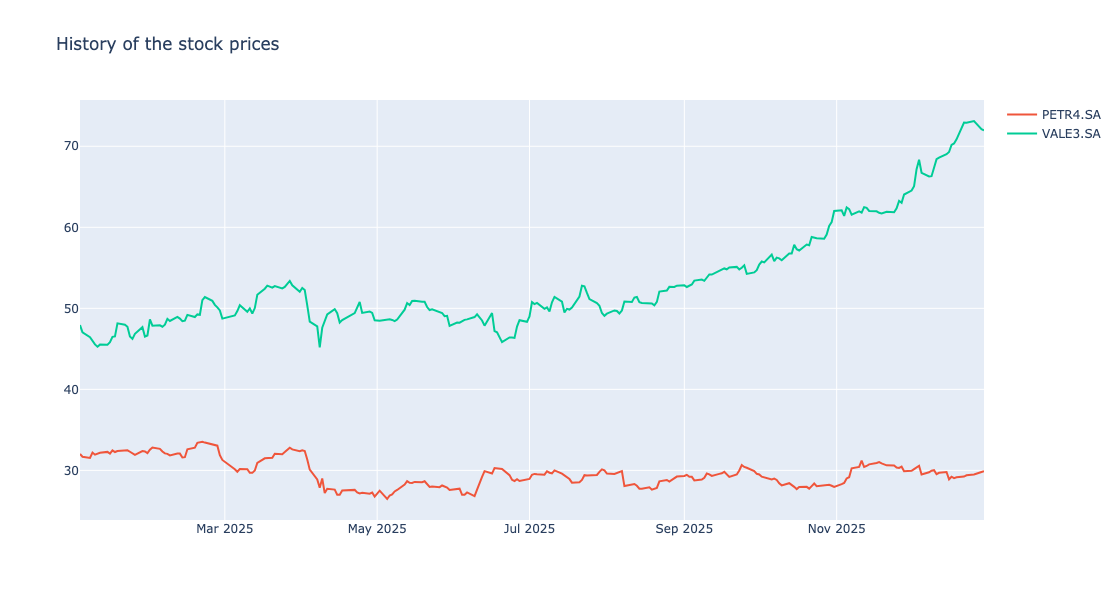

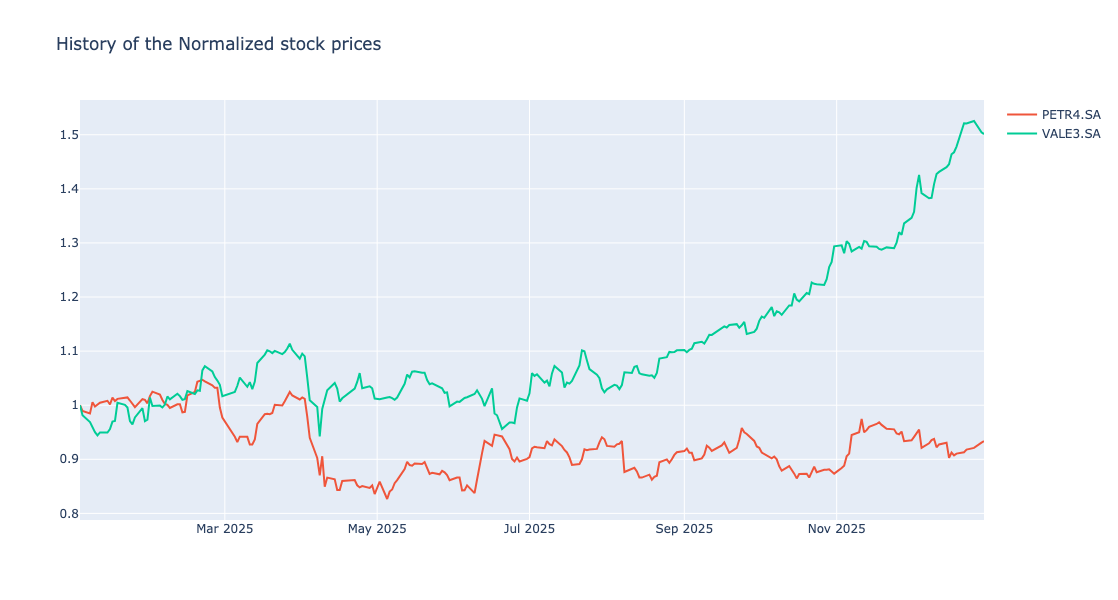

0

In [64]:
# ====================================
# Plots
# ====================================
Generate_Plot(df_basket)
Generate_Normalized_Plot(df_basket)

In [65]:
# =========================================================
# Log return calculator
# =========================================================
df_Log_returns = Log_Return_Calculator(df_basket)
display(df_Log_returns)

Ticker,PETR4.SA,VALE3.SA
Date,,
2025-01-03,-0.010663,-0.018793
2025-01-06,-0.004684,-0.012855
2025-01-07,0.021042,-0.009751
2025-01-08,-0.008146,-0.009653
2025-01-09,0.004352,-0.006227
...,...,...
2025-12-22,0.002898,0.028798
2025-12-23,0.005363,-0.000274
2025-12-26,0.003294,0.003013


In [66]:
# =========================================================
# Annualized Volatility Calculator
# =========================================================

annualized_volatility = Annualized_Standard_Deviation(df_Log_returns,trading_days)
Vol_PETR,Vol_VALE = annualized_volatility
print(f"Annualized Volatility PETR = {Vol_PETR * 100:.2f}%")
print(f"Annualized Volatility VALE = {Vol_VALE * 100:.2f}%")

Annualized Volatility PETR = 22.72%
Annualized Volatility VALE = 21.89%


In [67]:
# =========================================================
# Annualized Covariance Matrix
# =========================================================

Matrix_Cov = Annualized_Covariance_Matrix(df_Log_returns,trading_days)
display(Matrix_Cov)

Ticker,PETR4.SA,VALE3.SA
Ticker,,
PETR4.SA,0.051605,0.010752
VALE3.SA,0.010752,0.047939


In [68]:
# =========================================================
# Generation of the prices of the stocks
# =========================================================

# 1. Define market and contract assumptions
selic_rate = 0.15           # 15% per year
years_to_maturity = 0.5     # 6 months until maturity
simulations = 1*10**7       # Running ten million of tests ("steady state")

# 2. Execute the simulation
S_T_future_prices_matrix = Simulate_Basket_Prices(df_basket = df_basket, 
                                                  MCov= Matrix_Cov, 
                                                  annualized_volatility = annualized_volatility, 
                                                  r = selic_rate, 
                                                  T = years_to_maturity, 
                                                  M = simulations)

# Monte Carlo generation of the trajectories
df_simulations = pd.DataFrame(S_T_future_prices_matrix.T, columns=df_basket.columns)
df_simulations.index.name = 'Simulation'
display(df_simulations)

Ticker,PETR4.SA,VALE3.SA
Simulation,,
0,33.512092,66.521158
1,29.151159,58.932885
2,24.990605,93.803385
3,40.515750,85.062546
4,30.973345,80.801257
...,...,...
9999995,26.677610,70.520896
9999996,28.126102,68.029900
9999997,29.740429,76.602717


In [69]:
# =========================================================
# Generation of the prices of the basket
# =========================================================

# Calculate the initial basket value today (S0_basket)
S0 = df_basket.iloc[-1].values
S0_basket = np.dot(S0, weights_basket)

# Set the strike price (e.g., K equal to the current basket price "At-the-Money")
K_strike = S0_basket 

# Calculate the option price
basket_option_premium = Price_Basket_Option(df_simulations = df_simulations,
                                            weights_basket = weights_basket,
                                            K = K_strike,
                                            r = selic_rate,
                                            T = years_to_maturity,
                                            option_type = "call")
print("="*60)
print(f"Current Basket Value Today (S0): BRL {S0_basket:.2f}")
print(f"Option Strike Price (K): BRL {K_strike:.2f}")
print(f"Calculated Basket Option Fair Value: BRL {basket_option_premium:.2f}")
print("="*60)

Current Basket Value Today (S0): BRL 38.30
Option Strike Price (K): BRL 38.30
Calculated Basket Option Fair Value: BRL 3.56


Running convergence test...
M = 100     | Option Price = BRL 3.3736
M = 250     | Option Price = BRL 3.2829
M = 500     | Option Price = BRL 3.7153
M = 750     | Option Price = BRL 3.4774
M = 1000    | Option Price = BRL 3.5995
M = 2000    | Option Price = BRL 3.6780
M = 3000    | Option Price = BRL 3.6300
M = 4000    | Option Price = BRL 3.5924
M = 5000    | Option Price = BRL 3.5453
M = 10000   | Option Price = BRL 3.5317
M = 20000   | Option Price = BRL 3.5083
M = 50000   | Option Price = BRL 3.5814
M = 60000   | Option Price = BRL 3.5500
M = 10000   | Option Price = BRL 3.5179
M = 20000   | Option Price = BRL 3.5505
M = 25000   | Option Price = BRL 3.5518
M = 30000   | Option Price = BRL 3.5568
M = 40000   | Option Price = BRL 3.5746
M = 50000   | Option Price = BRL 3.5376
M = 60000   | Option Price = BRL 3.5443
M = 75000   | Option Price = BRL 3.5815
M = 80000   | Option Price = BRL 3.5526
M = 90000   | Option Price = BRL 3.5624
M = 100000  | Option Price = BRL 3.5791
M = 120000  

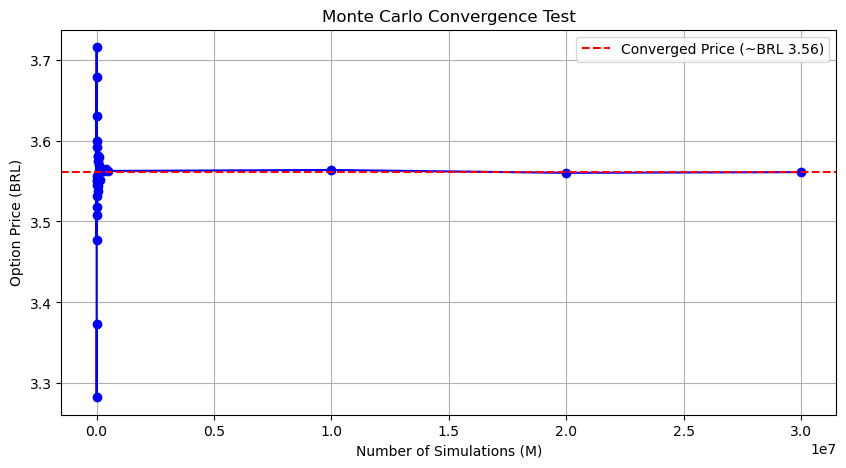

In [70]:
# =========================================================
# Verification of Results
# =========================================================

# Since we do not have an analytical result for this model (like Black-Scholes for vanilla options),
# we need to test and observe the convergence property of the results as the number of iterations increases.

Run_Convergence_Test(
    df_basket = df_basket,
    Mcov = Matrix_Cov,
    annualized_volatility = annualized_volatility,
    r = selic_rate,
    T = years_to_maturity,
    K = K_strike,
    weights_basket = weights_basket
)